## Cube generation for `SCS2: Forest recovery post disturbance` in the EO-LINCS project

### Scientific Case Study 2: Forest recovery post disturbance

**Objective**: The SCS2 aims to estimate canopy height and above-ground biomass maps using deep learning methods based on remote sensing data. The canopy height and above-ground biomass maps are subsequently used to calculate recovery curves, which in turn can be used to estimate carbon budget.

**Outcomes**: New high-resolution height/biomass maps that are expected to enable the monitoring of biomass at finer scales, in particular the impact of fine scale forest disturbances due to management practices such as thinning and the impact of natural disturbances (insects attacks, droughts, fires and windthrown in regions of interest). Analysis of forest recovery depending on environmental factors (such as climate, soil composition and pH) and the nature and intensity of disturbance shall aid in the optimization of forest management considering potential increased future disturbances.

**Requried datasets**:

* [CLMS Forest Type 2015](https://land.copernicus.eu/en/products/high-resolution-layer-forests-and-tree-cover/forest-type-2015)
* [Global Age Mapping Integration (GAMI) – Global forest age ensemble](https://simonbesnard1.github.io/eoforeststac/#/structure-demography/GAMI/collection.json)
* [ForestPaths – European Tree Genus Map 2020](https://simonbesnard1.github.io/eoforeststac/#/structure-demography/FORESTPATHS_GENUS/collection.json)
* [Liu et al. – Europe aboveground biomass, canopy cover, and canopy height (30 m)](https://simonbesnard1.github.io/eoforeststac/#/biomass-carbon/LIU_BIOMASS/collection.json)
* [ESA-CCI Biomass v6.0](https://catalogue.ceda.ac.uk/uuid/95913ffb6467447ca72c4e9d8cf30501/)
* [European Forest Disturbance Atlas](https://zenodo.org/records/13333034)

-------------------------------------------------------------

## Overview of the Cube Generation Pipeline

This notebook demonstrates how users can access the required datasets via the [xcube Multi-Source Data Store](https://xcube-dev.github.io/xcube-multistore/). All parameters controlling the cube generation workflow are defined in the configuration file [config.yml](config.yml).

Comprehensive documentation of the configuration schema is available on the [documentation webpage](https://xcube-dev.github.io/xcube-multistore/config/). A step-by-step example showing how to set up a configuration file—while extracting information from multiple data stores—is provided here:  
[Setup Config YAML File](https://xcube-dev.github.io/xcube-multistore/examples/setup_config/).

In this notebook, we provide:
- A concise preview of the configuration file (summarized in a table)
- The requested geospatial domain
- A walkthrough of the cube generation process

---

### Requirements

Before proceeding, ensure that all required dependencies are installed. The recommended approach is to create a Conda/Mamba environment using the provided environment specification:

```bash
conda/mamba env create -f environment.yml
```
The corresponding file can be found here: [environment.yml](../environment.yml)

After creation, activate the environment:
```bash
conda activate eo-lincs-scs2
```

Next, access to CLMS data requires authentication credentials for the CLMS API, as described in the [xcube-clms documentation](https://github.com/xcube-dev/xcube-clms#create-credentials-to-access-the-clms-api).

These credentials should be stored in a JSON file (in this example `clms-credentials.json`) and are loaded during the cube generation process as specified in the configuration file [config.yml](config.yml).

Note that both the filename and the relative path to the credentials file are user-defined and can be adjusted if needed, provided they are correctly referenced in the configuration.



--- 
### Running the Pipeline

Once all dependencies are installed and the environment is activated, the final data cubes can be generated by executing the provided notebook.

The resulting outputs will be written to the `data` directory, as specified in the configuration file [config.yml](config.yml). Users can modify the configuration to change the root directory of the `storage` data store if needed.

At the end of the notebook, basic visualizations of the generated data cubes are provided for quick inspection and validation.


---

## Imports and cluster setup

Let's import the `MultiSourceDataStore`

In [1]:
from dask.distributed import Client, LocalCluster
import matplotlib.pyplot as plt
from xcube_multistore.multistore import MultiSourceDataStore

We create a local Dask cluster to limit resource usage during cube generation. A larger memory allocation per worker is necessary because the GAMI dataset is relatively large, containing 20 members that are aggregated during the generation process. The number of workers can be reduced if insufficient RAM is available, although this will come at the cost of slower processing.

In [2]:
cluster = LocalCluster(
    n_workers=4,
    threads_per_worker=1,
    memory_limit="6GB",   # per worker
    dashboard_address=':8787',
)
client = Client(cluster)
client.dashboard_link

'http://127.0.0.1:8787/status'

---
## Configuration of the Cube Generation Process

You can explore the available options for the configuration file using the function `get_config_schema()`. Run it and expand the fields to see all the properties that can be set, in combination with the [Configuration Guide](https://xcube-dev.github.io/xcube-multistore/config/).  

For guidance on creating your configuration file, you can also refer to the notebook [setup_config.ipynb](https://xcube-dev.github.io/xcube-multistore/examples/setup_config/) or consult the [Configuration Guide](https://xcube-dev.github.io/xcube-multistore/config/) in the documentation.

In [3]:
MultiSourceDataStore.get_config_schema()

We can now initialize the `MultiSourceDataStore` by providing the path to `config.yml`, which is located in the same directory as this notebook.

Here are a few notes explaining what happens during cube generation:

- The dataset `forest-type-2015` from CLMS is preloaded using [xcube-clms](https://github.com/xcube-dev/xcube-clms). Preloading is required because accessing the dataset involves sending a request to the CLMS API, queuing the request, and downloading the data before processing can begin. Once downloaded, the data is stored in the local cache datastore for subsequent use. (We focus on the 2015 dataset because more recent datasets have already been migrated to WekEO or CDSE. The migration for additional datasets is not yet complete. We contacted CLMS support regarding a roadmap, but did not receive a definitive timeline. As a result, we decided to wait for further updates before implementing access to newer CLMS datasets.)

- The `config.yml` also uses the `custom_processing` feature of xcube-multistore. This allows a custom processing function to be applied to each dataset individually. In this example, we define a module called `utils`, which contains a function that takes an `xarray.Dataset` as input and returns a modified `xarray.Dataset`. More details about `custom_processing` can be found in the [xcube-multistore documentation](https://xcube-dev.github.io/xcube-multistore/config/#custom_processing).


> **Note:** The following cell will produce a `NoConformsTo` warning. This occurs because the EO Forest STAC is a static STAC catalog rather than a full STAC API. It does not expose search capabilities or advertise STAC API conformance classes. This warning is harmless, as [xcube-stac](https://github.com/xcube-dev/xcube-stac#overview) can also work with static STAC catalogs.

In [3]:
msds = MultiSourceDataStore("config.yml")

/home/konstantin/micromamba/envs/eo-lincs-scs2/lib/python3.13/site-packages/pystac_client/client.py:191: NoConformsTo: Server does not advertise any conformance classes.
  warnings.warn(NoConformsTo())


Next, we can display the overview of the configuration file for each dataset.

In [5]:
msds.display_config()

User-defined ID,Data Store ID,Data Store Params,Data ID,Open Data Params,Grid-Mapping,Format
forest_type_2015,clms,CLMS credentials,forest-type-2015|FTY_2015_020m_eu_03035_d04_E30N20.zarr,-,"bbox: [3401404, 2346797, 3556068, 2539337]; spatial_res: 30; crs: EPSG:3035; tile_size: 2048",Zarr
gami,stac,url: https://s3.gfz-potsdam.de/dog.atlaseo-glm.eo-gridded-data/collections/public/catalog.json,structure-demography/GAMI/GAMI_v3.1/GAMI_v3.1.json,-,"bbox: [3401404, 2346797, 3556068, 2539337]; spatial_res: 30; crs: EPSG:3035; tile_size: 2048",Zarr
forestpaths_genus,stac,url: https://s3.gfz-potsdam.de/dog.atlaseo-glm.eo-gridded-data/collections/public/catalog.json,structure-demography/FORESTPATHS_GENUS/FORESTPATHS_GENUS_v0.0.1/FORESTPATHS_GENUS_v0.0.1.json,-,"bbox: [3401404, 2346797, 3556068, 2539337]; spatial_res: 30; crs: EPSG:3035; tile_size: 2048",Zarr
liu,stac,url: https://s3.gfz-potsdam.de/dog.atlaseo-glm.eo-gridded-data/collections/public/catalog.json,biomass-carbon/LIU_BIOMASS/LIU_BIOMASS_v0.1/LIU_BIOMASS_v0.1.json,-,"bbox: [3401404, 2346797, 3556068, 2539337]; spatial_res: 30; crs: EPSG:3035; tile_size: 2048",Zarr
esa_cci_biomass,cciodp,-,esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-platform.MERGED.6-0.100m,-,"bbox: [3401404, 2346797, 3556068, 2539337]; spatial_res: 30; crs: EPSG:3035; tile_size: 2048",Zarr
efda,stac,url: https://s3.gfz-potsdam.de/dog.atlaseo-glm.eo-gridded-data/collections/public/catalog.json,disturbance-change/EFDA/EFDA_v2.1.1/EFDA_v2.1.1.json,-,"bbox: [3401404, 2346797, 3556068, 2539337]; spatial_res: 30; crs: EPSG:3035; tile_size: 2048",Zarr


We can display the selected bounding box as shown in the following cell.

In [6]:
msds.display_geolocations()

---

## Cube Generation

Cube generation is triggered with a single command and proceeds in two stages:

### 1. Preloading

The workflow first preloads all required datasets from their respective stores:

- **clms**: Preloads the Forest Type map for 2015.

Preloading ensures that all input files are available locally for processing.

### 2. Sequential Processing

Once preloading is complete, each dataset is processed sequentially. The workflow applies the following steps as needed:

- Spatial resampling to a common target grid  
- Temporal aggregation or other dataset-specific preprocessing  
- Writing the final datacube to the `data/` output directory  

### Dataset Notes

- **forest_type_2015**: Loaded from the local CLMS cache (preloading output). User-defined processing specifications are applied during cube generation.

- **gami**: Aggregated using the custom function `utils.modify_gami` and resampled according to workflow specifications.

- **forestpaths_genus**, **liu** and **efda**: Accessed lazily via the EOForest STAC store using xcube’s STAC datastore, with resampling performed on the fly.

- **biomass_esa_cci**: Accessed lazily via the xcube ESA CCI datastore, with on-the-fly resampling.

- **efda** Accessed lazily via the EOForest STAC store using xcube’s STAC datastore, with resampling performed on the fly.


> Note: The warning `"RuntimeWarning: invalid value encountered in divide"` originates from NumPy when performing calculations involving `NaN` values. These warnings are harmless and can be safely ignored. 

In [7]:
msds.generate()

Data ID,Status,Progress,Message,Exception
forest-type-2015|FTY_2015_020m_eu_03035_d04_E30N20,COMPLETED,100%,Task ID 81148080445: Preloading Complete.,-


Dataset identifier,Status,Message,Exception
forest_type_2015,COMPLETED,Dataset 'forest_type_2015' finished: 0:00:09,-
gami,COMPLETED,Dataset 'gami' finished: 0:04:55,-
forestpaths_genus,COMPLETED,Dataset 'forestpaths_genus' finished: 0:00:36,-
liu,COMPLETED,Dataset 'liu' finished: 0:00:26,-
esa_cci_biomass,COMPLETED,Dataset 'esa_cci_biomass' finished: 0:07:28,-
efda,COMPLETED,Dataset 'efda' finished: 0:03:07,-


/home/konstantin/micromamba/envs/eo-lincs-scs2/lib/python3.13/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 877.13 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/konstantin/micromamba/envs/eo-lincs-scs2/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/konstantin/micromamba/envs/eo-lincs-scs2/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/konstantin/micromamba/envs/eo-lincs-scs2/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/ho

----

## Initial Inspection of the Generated Datasets

After cube generation has completed, the datasets can be opened using the xcube datastore framework API as usual.

Note that the multi-source datastore expects a datastore named `storage`. This datastore is defined in the `data_stores` section of the `config.yml` configuration file.


In [8]:
ds = msds.stores.storage.open_data("gami.zarr")
ds

<xarray.Dataset> Size: 132MB
Dimensions:      (y: 6418, x: 5156)
Coordinates:
  * y            (y) float64 51kB 2.539e+06 2.539e+06 ... 2.347e+06 2.347e+06
  * x            (x) float64 41kB 3.401e+06 3.401e+06 ... 3.556e+06 3.556e+06
    spatial_ref  int64 8B ...
    time         datetime64[ns] 8B ...
Data variables:
    forest_age   (y, x) float32 132MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Attributes:
    stac_catalog_url:    https://s3.gfz-potsdam.de/dog.atlaseo-glm.eo-gridded...
    stac_item_id:        GAMI_v3.1
    xcube_stac_version:  1.3.1

We select a single variable at one time step, downsample it, and plot the result to quickly preview the data.

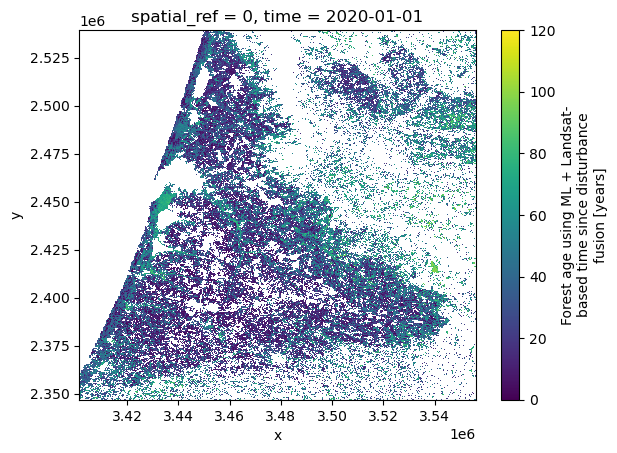

In [9]:
ds["forest_age"][::5, ::5].plot(vmin=0, vmax=120)

The same quicklook can be created for any generated dataset.

In [10]:
ds = msds.stores.storage.open_data("forestpaths_genus.zarr")
ds

<xarray.Dataset> Size: 265MB
Dimensions:      (y: 6418, x: 5156)
Coordinates:
  * y            (y) float64 51kB 2.539e+06 2.539e+06 ... 2.347e+06 2.347e+06
  * x            (x) float64 41kB 3.401e+06 3.401e+06 ... 3.556e+06 3.556e+06
    spatial_ref  int64 8B ...
    time         datetime64[ns] 8B ...
Data variables:
    genus        (y, x) float64 265MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Attributes:
    stac_catalog_url:    https://s3.gfz-potsdam.de/dog.atlaseo-glm.eo-gridded...
    stac_item_id:        FORESTPATHS_GENUS_v0.0.1
    xcube_stac_version:  1.3.1

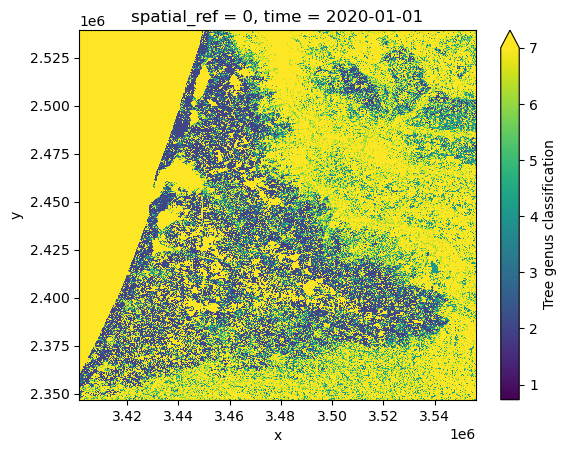

In [11]:
ds["genus"][::5, ::5].plot(vmax=7)

In [4]:
ds = msds.stores.storage.open_data("forest_type_2015.zarr")
ds

<xarray.Dataset> Size: 265MB
Dimensions:                            (y: 6418, x: 5156)
Coordinates:
  * y                                  (y) float64 51kB 2.539e+06 ... 2.347e+06
  * x                                  (x) float64 41kB 3.401e+06 ... 3.556e+06
    spatial_ref                        int64 8B ...
Data variables:
    FTY_2015_020m_eu_03035_d04_E30N20  (y, x) float64 265MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Attributes:
    AREA_OR_POINT:  Area
    DataType:       Thematic

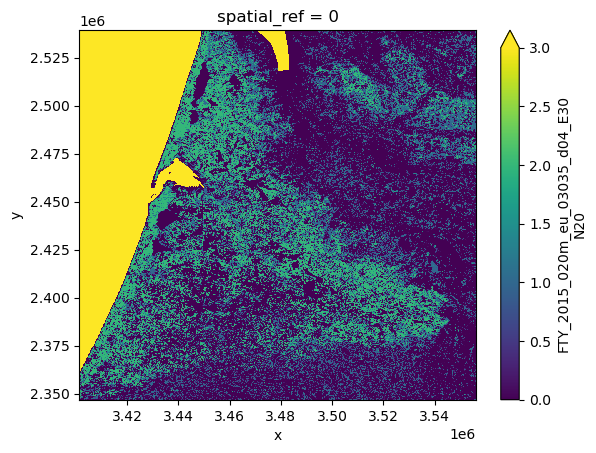

In [5]:
ds["FTY_2015_020m_eu_03035_d04_E30N20"][::5, ::5].plot(vmax=3)

In [14]:
ds = msds.stores.storage.open_data("liu.zarr")
ds

<xarray.Dataset> Size: 794MB
Dimensions:              (y: 6418, x: 5156)
Coordinates:
  * y                    (y) float64 51kB 2.539e+06 2.539e+06 ... 2.347e+06
  * x                    (x) float64 41kB 3.401e+06 3.401e+06 ... 3.556e+06
    spatial_ref          int64 8B ...
    time                 datetime64[ns] 8B ...
Data variables:
    aboveground_biomass  (y, x) float64 265MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    canopy_cover         (y, x) float64 265MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    canopy_height        (y, x) float64 265MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Attributes:
    stac_catalog_url:    https://s3.gfz-potsdam.de/dog.atlaseo-glm.eo-gridded...
    stac_item_id:        LIU_BIOMASS_v0.1
    xcube_stac_version:  1.3.1

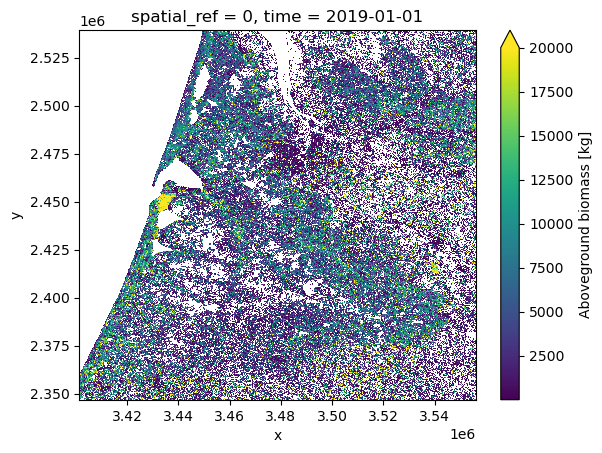

In [15]:
ds["aboveground_biomass"][::5, ::5].plot(vmax=20000)

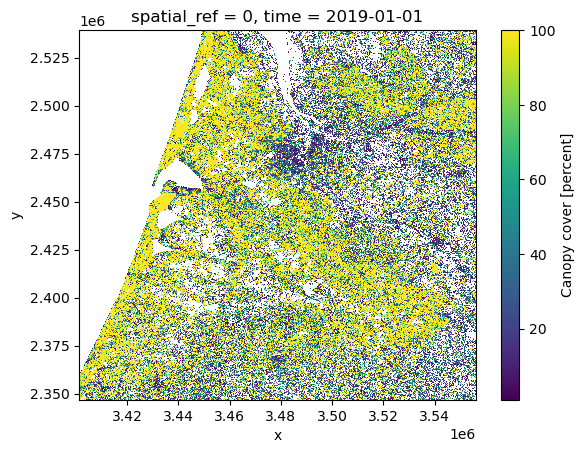

In [16]:
ds["canopy_cover"][::5, ::5].plot()

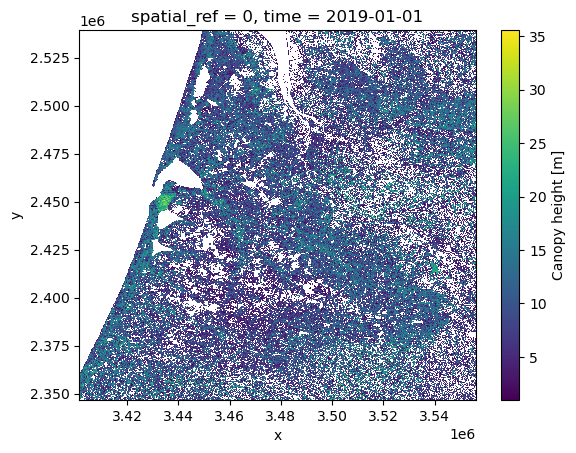

In [17]:
ds["canopy_height"][::5, ::5].plot()

In [18]:
ds = msds.stores.storage.open_data("efda.zarr")
ds

<xarray.Dataset> Size: 1GB
Dimensions:            (time: 39, y: 6418, x: 5156)
Coordinates:
  * time               (time) datetime64[ns] 312B 1985-01-01 ... 2023-01-01
  * y                  (y) float64 51kB 2.539e+06 2.539e+06 ... 2.347e+06
  * x                  (x) float64 41kB 3.401e+06 3.401e+06 ... 3.556e+06
    spatial_ref        int64 8B ...
Data variables:
    disturbance_agent  (time, y, x) uint8 1GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
Attributes:
    stac_catalog_url:    https://s3.gfz-potsdam.de/dog.atlaseo-glm.eo-gridded...
    stac_item_id:        EFDA_v2.1.1
    xcube_stac_version:  1.3.1

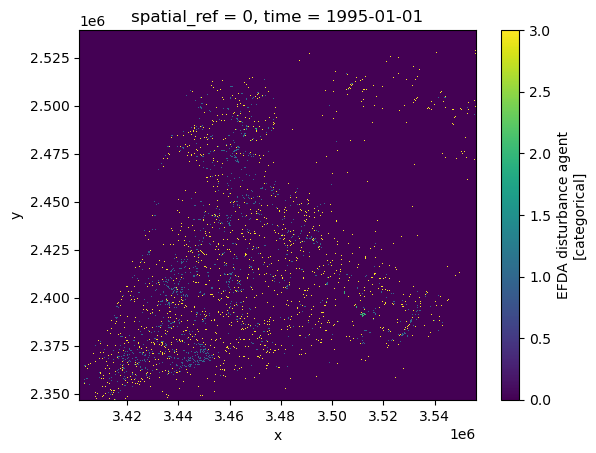

In [19]:
ds["disturbance_agent"].isel(time=10)[::5, ::5].plot()

In [20]:
ds = msds.stores.storage.open_data("esa_cci_biomass.zarr")
ds

<xarray.Dataset> Size: 3GB
Dimensions:      (time: 10, y: 6418, x: 5156)
Coordinates:
  * time         (time) datetime64[ns] 80B 2007-07-02T11:59:59 ... 2022-07-02...
  * y            (y) float64 51kB 2.539e+06 2.539e+06 ... 2.347e+06 2.347e+06
  * x            (x) float64 41kB 3.401e+06 3.401e+06 ... 3.556e+06 3.556e+06
    spatial_ref  int64 8B ...
Data variables:
    agb          (time, y, x) float32 1GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    agb_sd       (time, y, x) float32 1GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    date_created:            2026-06-30T10:24:04.780645
    history:                 [{'cube_params': {'time_range': ['2007-01-01T00:...
    processing_level:        L4
    time_coverage_duration:  P5843DT23H59M59S
    time_coverage_end:       2022-12-31T23:59:59
    time_coverage_start:     2007-01-01T00:00:00
    title:                   esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-plat...

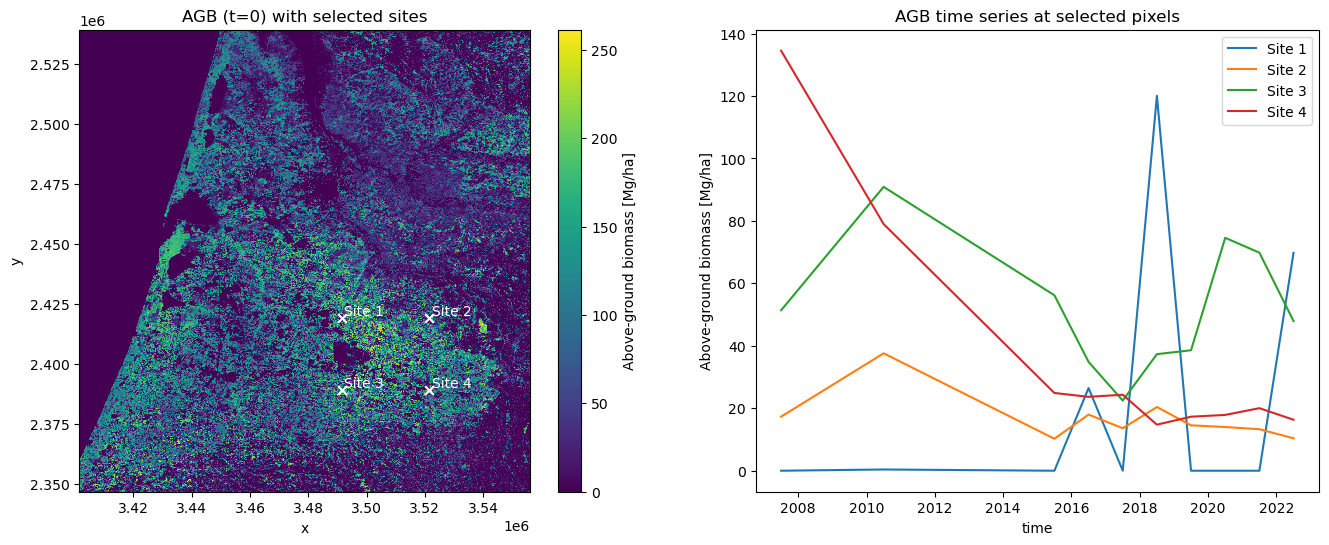

In [21]:
agb_coarse = ds["agb"][:, ::5, ::5]

sites = {
    "Site 1": (800, 600),
    "Site 2": (800, 800),
    "Site 3": (1000, 600),
    "Site 4": (1000, 800),
}

fig, (ax_map, ax_ts) = plt.subplots(1, 2, figsize=(16, 6))

agb_coarse.isel(time=0).plot(ax=ax_map)
ax_map.set_title("AGB (t=0) with selected sites")

for name, (iy, ix) in sites.items():
    ts = agb_coarse.isel(y=iy, x=ix)
    ts.plot(ax=ax_ts, label=name)
    ax_map.scatter(ts.x, ts.y, color="white", s=40, marker="x")
    ax_map.text(ts.x + 1000, ts.y + 1000, name, color="white", fontsize=10)

ax_ts.set_title("AGB time series at selected pixels")
ax_ts.legend()

Lastly, we perform a clean-up by closing the Dask `Client` and `Cluster`, ensuring that the notebook can be safely rerun without unexpected side effects.


In [22]:
client.close()
cluster.close()